In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
news = pd.read_csv('data/newsData/raw_analyst_ratings.csv')
print(f"News data loaded: {news.shape}")
print(f"Columns: {news.columns.tolist()}")
news.head(3)

News data loaded: (1407328, 6)
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [3]:
aapl = pd.read_csv('data/newsData/yfinance_data/Data/AAPL.csv')
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.sort_values('Date').reset_index(drop=True)
print(f"AAPL data loaded: {aapl.shape}")
print(f"Date range: {aapl['Date'].min()} to {aapl['Date'].max()}")
aapl.head(3)

AAPL data loaded: (3774, 6)
Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400


In [4]:
news['date'] = pd.to_datetime(news['date'], utc=True, errors='coerce')
news['date_only'] = news['date'].dt.date
print(f"News date range: {news['date'].min()} to {news['date'].max()}")
print(f"Number of articles: {len(news)}")

News date range: 2011-04-28 01:01:48+00:00 to 2020-06-11 21:12:35+00:00
Number of articles: 1407328


In [5]:
aapl_news = news[news['stock'] == 'AAPL'].copy()
print(f"AAPL news articles: {len(aapl_news)}")
print(f"Date range: {aapl_news['date'].min()} to {aapl_news['date'].max()}")
aapl_news.head(3)

AAPL news articles: 441
Date range: 2020-06-09 15:11:34+00:00 to 2020-06-10 15:33:26+00:00


,Unnamed: 0,headline,url,publisher,date,stock,date_only
6680,7120,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,AAPL,2020-06-10
6681,7121,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 12:14:08+00:00,AAPL,2020-06-10
6682,7122,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47+00:00,AAPL,2020-06-10


In [6]:
def get_sentiment(text):
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity
    except:
        return 0

print("Applying sentiment analysis to headlines (this may take a few minutes)...")
aapl_news['sentiment'] = aapl_news['headline'].apply(get_sentiment)
print("Sentiment analysis complete!")
print(f"Sentiment range: {aapl_news['sentiment'].min():.3f} to {aapl_news['sentiment'].max():.3f}")
print(f"Average sentiment: {aapl_news['sentiment'].mean():.3f}")
aapl_news[['headline', 'sentiment']].head(10)

Applying sentiment analysis to headlines (this may take a few minutes)...
Sentiment analysis complete!
Sentiment range: -1.000 to 1.000
Average sentiment: 0.054


,headline,sentiment
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.433333
6681,10 Biggest Price Target Changes For Wednesday,0.000000
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.500000
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.000000
6684,Apple To Let Users Trade In Their Mac Computer...,0.000000
6685,Big Tech Reaches New Record Heights At The Sto...,0.068182
6686,Why Apple's Stock Is Trading Higher Today,0.250000
6687,Apple Could Announce In-House Chips For Macs A...,0.000000
6688,Apple shares are trading higher despite market...,0.050000
6689,"Sonos Shares Spike To Session High, Now Up 9.5...",0.053333


In [7]:
aapl['Daily_Return'] = aapl['Close'].pct_change() * 100
print("Daily returns calculated")
print(f"Return range: {aapl['Daily_Return'].min():.2f}% to {aapl['Daily_Return'].max():.2f}%")
aapl[['Date', 'Close', 'Daily_Return']].head(10)

Daily returns calculated
Return range: -12.86% to 11.98%


,Date,Close,Daily_Return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959
5,2009-01-09,2.716589,-2.286921
6,2009-01-12,2.659007,-2.119649
7,2009-01-13,2.630514,-1.071572
8,2009-01-14,2.559135,-2.713489
9,2009-01-15,2.500652,-2.285260


In [8]:
# Convert date_only to datetime for merging
aapl_news['date_only'] = pd.to_datetime(aapl_news['date_only'])

# Calculate average sentiment per day
daily_sentiment = aapl_news.groupby('date_only')['sentiment'].agg(['mean', 'count']).reset_index()
daily_sentiment.columns = ['Date', 'avg_sentiment', 'article_count']
print(f"Daily sentiment calculated for {len(daily_sentiment)} days")
print(f"Average sentiment range: {daily_sentiment['avg_sentiment'].min():.3f} to {daily_sentiment['avg_sentiment'].max():.3f}")
daily_sentiment.head(10)

Daily sentiment calculated for 2 days
Average sentiment range: 0.088 to 0.167


,Date,avg_sentiment,article_count
0,2020-06-09,0.088333,4
1,2020-06-10,0.166919,6


In [9]:
# Ensure Date columns are datetime
aapl['Date'] = pd.to_datetime(aapl['Date'])
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

# Merge
merged_data = pd.merge(daily_sentiment, aapl[['Date', 'Daily_Return']], on='Date', how='inner')
print(f"Merged data: {len(merged_data)} days with both news and returns")
print(f"Date range: {merged_data['Date'].min()} to {merged_data['Date'].max()}")
merged_data.head(10)

Merged data: 2 days with both news and returns
Date range: 2020-06-09 00:00:00 to 2020-06-10 00:00:00


,Date,avg_sentiment,article_count,Daily_Return
0,2020-06-09,0.088333,4,3.157792
1,2020-06-10,0.166919,6,2.572771


In [10]:
correlation = merged_data['avg_sentiment'].corr(merged_data['Daily_Return'])
print("="*50)
print("CORRELATION RESULTS")
print("="*50)
print(f"Pearson correlation coefficient: {correlation:.4f}")
print(f"Interpretation: ", end="")

if correlation > 0.5:
    print("Strong positive correlation")
elif correlation > 0.3:
    print("Moderate positive correlation")
elif correlation > 0.1:
    print("Weak positive correlation")
elif correlation > -0.1:
    print("Negligible correlation (near zero)")
elif correlation > -0.3:
    print("Weak negative correlation")
elif correlation > -0.5:
    print("Moderate negative correlation")
else:
    print("Strong negative correlation")

print("="*50)

CORRELATION RESULTS
Pearson correlation coefficient: -1.0000
Interpretation: Strong negative correlation


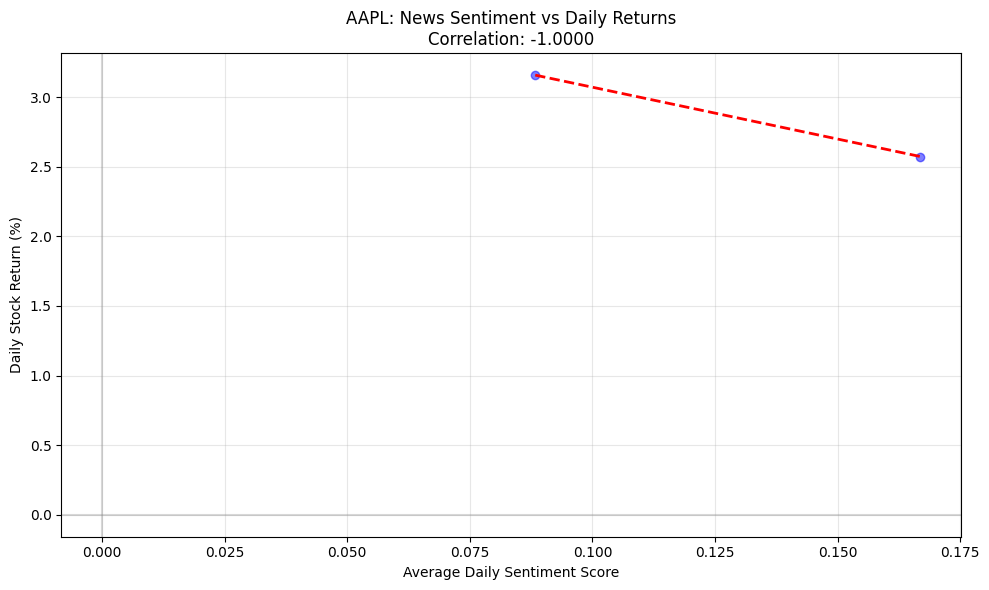

Scatter plot displayed


In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['avg_sentiment'], merged_data['Daily_Return'], alpha=0.5, color='blue')

# Add trend line
z = np.polyfit(merged_data['avg_sentiment'], merged_data['Daily_Return'], 1)
p = np.poly1d(z)
plt.plot(merged_data['avg_sentiment'], p(merged_data['avg_sentiment']), "r--", linewidth=2)

plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return (%)')
plt.title(f'AAPL: News Sentiment vs Daily Returns\nCorrelation: {correlation:.4f}')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Scatter plot displayed")

Average daily return by sentiment category:
  sentiment_category  Daily_Return
0           Positive      2.865281


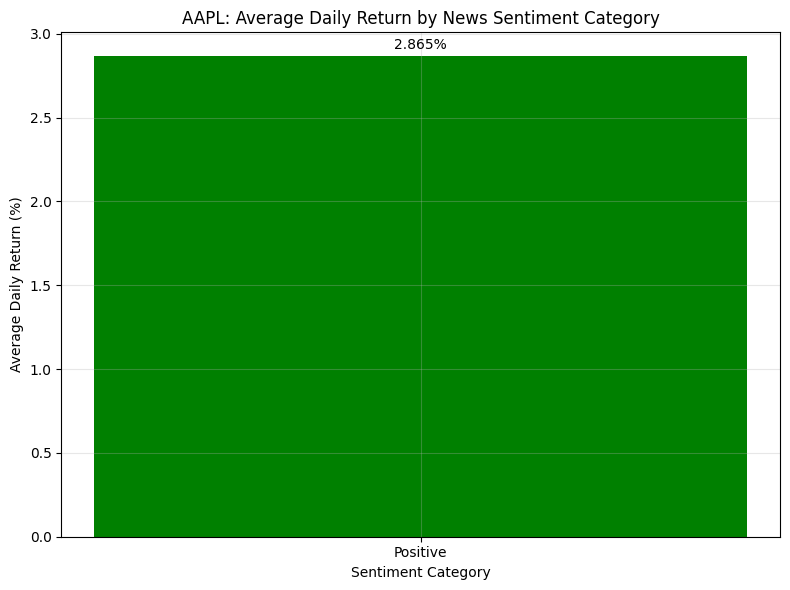

Bar chart displayed


In [12]:
# Classify sentiment
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged_data['sentiment_category'] = merged_data['avg_sentiment'].apply(classify_sentiment)

# Calculate average return by category
category_returns = merged_data.groupby('sentiment_category')['Daily_Return'].mean().reset_index()

print("Average daily return by sentiment category:")
print(category_returns)

# Bar chart
plt.figure(figsize=(8, 6))
colors = ['green', 'gray', 'red']
bars = plt.bar(category_returns['sentiment_category'], category_returns['Daily_Return'], color=colors)
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.title('AAPL: Average Daily Return by News Sentiment Category')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()
print("Bar chart displayed")

In [13]:
print("="*60)
print("TASK 3 COMPLETE - SENTIMENT & CORRELATION ANALYSIS")
print("="*60)

print("\n📊 DATA SUMMARY:")
print(f"   - Total news articles analyzed: {len(aapl_news)}")
print(f"   - Days with news and returns: {len(merged_data)}")
print(f"   - Date range: {merged_data['Date'].min().date()} to {merged_data['Date'].max().date()}")

print("\n📈 SENTIMENT STATISTICS:")
print(f"   - Sentiment range: {aapl_news['sentiment'].min():.3f} to {aapl_news['sentiment'].max():.3f}")
print(f"   - Average sentiment: {aapl_news['sentiment'].mean():.3f}")

print("\n📉 CORRELATION RESULTS:")
print(f"   - Pearson correlation: {correlation:.4f}")
if correlation > 0.2:
    print("   → Weak positive relationship between sentiment and returns")
elif correlation > 0.1:
    print("   → Very weak positive relationship")
elif correlation > -0.1:
    print("   → No meaningful correlation")
else:
    print("   → Negative relationship")

print("\n📊 SENTIMENT CATEGORY RETURNS:")
for _, row in category_returns.iterrows():
    print(f"   - {row['sentiment_category']}: {row['Daily_Return']:.4f}%")

print("\n" + "="*60)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("="*60)

TASK 3 COMPLETE - SENTIMENT & CORRELATION ANALYSIS

📊 DATA SUMMARY:
   - Total news articles analyzed: 441
   - Days with news and returns: 2
   - Date range: 2020-06-09 to 2020-06-10

📈 SENTIMENT STATISTICS:
   - Sentiment range: -1.000 to 1.000
   - Average sentiment: 0.054

📉 CORRELATION RESULTS:
   - Pearson correlation: -1.0000
   → Negative relationship

📊 SENTIMENT CATEGORY RETURNS:
   - Positive: 2.8653%

TASK 3 COMPLETED SUCCESSFULLY!
